Parameters for 1_100G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000: wav_res=0.01715 A, disk_fill_phase_0=0.07355242566510173, res2d=100, res3d=4, mode=faconly, fac_r=[19], fac_long=[45], fac_lat=[0], fac_band=False, fac_band_low=[0], fac_band_high=[0], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03, hd_ld_file=test_phot.txt, fac_ld_file=test_fac_100G.txt
Parameters for 1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000: wav_res=0.01715 A, disk_fill_phase_0=0.07303077725612937, res2d=100, res3d=4, mode=faconly, fac_r=[15], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[0], fac_band_high=[0], ld=power2, v_eq=4000, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03, hd_ld_file=test_phot.txt, fac_ld_file=test_fac_100G.txt
Parameters for 1_100G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000: wav_res=0.01715 A, disk_fill_phase_0=0.07355242566510173, res2d=100, res3d=4, mode=faconly, fac_r=[19], fac_long=[-45], fac_lat=[0], fac_band=Fals

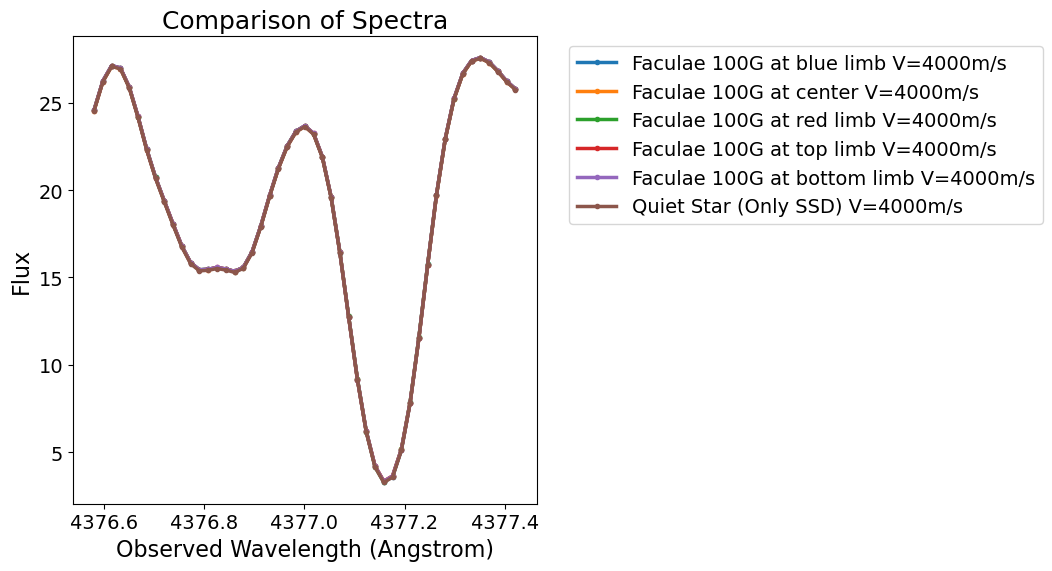

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory, get_simulation_params

# Set larger font sizes and thicker lines for overall readability
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'lines.markersize': 8
})

# Set to True to automatically grab all valid subdirectories in the current folder
compare_all_directories = False

if compare_all_directories == True:
    # Grab all subdirectories, ignoring cache, hidden folders, and wdrift folders
    dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        #and '4000' in d
        #and 'div2'  in d
        and 'band' in d
    ])
    directories_to_compare = {d: f"{d.strip('./')} (v={d.split('_v')[-1].strip('/')} m/s)" for d in dirs}
else:
    # Define the directories you want to compare as a dictionary { 'directory_path': 'custom label' }
    directories_to_compare = {
        # './wdrift_4375.6007_4376.3883_fac_lat0_long0_r15/': 'Label 1',
        # './wdrift_4375.6007_4376.3883_fac_lat45_long0_r15/': 'Label 2',
        
     #   './1_4376.5109_4377.4913_fac_lat0_long0_r0_v0/': 'Quiet Star (Only SSD) V=0m/s',
      #  './1_4376.5109_4377.4913_fac_lat0_long0_r0_v2000/': 'Quiet Star (Only SSD) V=2000m/s',
       # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v8000/': 'Quiet Star (Only SSD) V=8000m/s',

        #spots
        # './1_div2fac_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Spot at blue limb V=4000m/s',
        #     './1_div2fac_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Spot at center V=4000m/s',
        # './1_div2fac_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Spot at red limb V=4000m/s',
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Quiet Star (Only SSD) V=4000m/s',

        #faculae
        # './1_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae at blue limb V=4000m/s',
        # './1_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae at center V=4000m/s',
        # './1_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae at red limb V=4000m/s',
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Quiet Star (Only SSD) V=4000m/s',

        #bands
        # './1_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/': 'Equatorial band with Faculae V=4000m/s',
        # './1_4376.5109_4377.4913_band_lat45_90_v4000/': 'Polar band with Faculae V=4000m/s',

        #faculae 100G
        './1_100G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae 100G at blue limb V=4000m/s',
        './1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 100G at center V=4000m/s',
        './1_100G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae 100G at red limb V=4000m/s',
        './1_100G_4376.5109_4377.4913_fac_lat45_long0_r19_v4000/': 'Faculae 100G at bottom limb V=4000m/s',
        './1_100G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 100G at top limb V=4000m/s',

        './1_100G_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Quiet Star (Only SSD) V=4000m/s',


        # './1_4376.5109_4377.4913_fac_lat0_long45_r19_v0/': 'Star With Facular Spot',
        # './1_div2fac_4376.5109_4377.4913_fac_lat0_long45_r19_v0/': 'Star With Dark Spot',



    


        
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v4000/': 'Custom Label 3',
        # './1_4376.5109_4377.4913_fac_lat0_long0_r0_v8000/': 'Custom Label 4',
    }

plt.figure(figsize=(11, 6), dpi=100)

for directory, custom_label in directories_to_compare.items():
    try:
        # Retrieve the binned spectrum data
        bin_centers, binned_intensity = process_disk_directory(directory, phase_idx=0)
        
        # Try to read parameters for the legend
        params = get_simulation_params(directory)
        
        # Calculate wav_res: total angstroms / wavelength bins
        wav_res = (bin_centers[-1] - bin_centers[0]) / len(bin_centers)
        params = f"wav_res={wav_res:.5f} A, {params}"
        
        print(f"Parameters for {directory.strip('./')}: {params}")
        
        # Plot
        plt.plot(
            bin_centers, 
            binned_intensity, 
            marker='o', 
            markersize=3,
            linestyle='-', 
            linewidth=2.5, 
            alpha = 1.0,
            label=custom_label
        )
        
    except Exception as e:
        print(f"Error processing {directory}: {e}")

plt.xlabel('Observed Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title('Comparison of Spectra')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.xlim(4376.8,4377.4)
plt.tight_layout()
plt.savefig('comparison_phase0_binned_spectra.png', dpi=300, bbox_inches='tight')
plt.show()

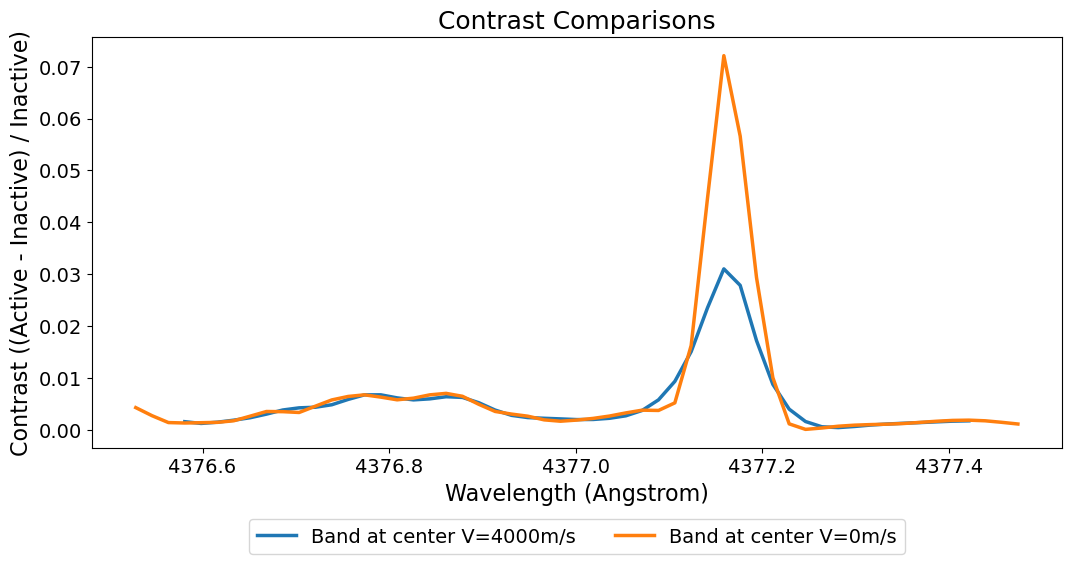

In [52]:
import os
import glob
import re
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory, get_simulation_params

# Choose whether to explicitly define directories or search for them
use_explicit_dirs = True

# --- Option 1: Explicitly define active directories and custom labels ---
explicit_active_dirs = {
    #spots
    # './1_div2fac_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Spot at blue limb',
    # './1_div2fac_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Spot at center',
    # './1_div2fac_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Spot at red limb',

    #faculae
    # './1_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae at blue limb',
   #  './1_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae at center',
    # './1_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae at red limb',

    #bands
    # './1_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/': 'Equatorial band with Faculae',
    # './1_4376.5109_4377.4913_band_lat45_90_v4000/': 'Polar band with Faculae',

    #faculae 100G
#     './1_100G_4376.5109_4377.4913_fac_lat0_long45_r19_v4000/': 'Faculae 100G at blue limb',
    # './1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 100G at center',
#     './1_100G_4376.5109_4377.4913_fac_lat0_long-45_r19_v4000/': 'Faculae 100G at red limb',
#    # './1_100G_4376.5109_4377.4913_fac_lat45_long0_r19_v4000/': 'Faculae 100G at bottom limb s',
     #'./1_100G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 100G at top limb',

    #activity comparison top limb
    # './1_100G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 100G at top limb',
    # './1_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 200G at top limb',
    # './1_300G_4376.5109_4377.4913_fac_lat-45_long0_r19_v4000/': 'Faculae 300G at top limb',

    #activity comparison disk center
    # './1_100G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 100G at disk center',
    # './1_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 200G at disk center',
    # './1_300G_4376.5109_4377.4913_fac_lat0_long0_r15_v4000/': 'Faculae 300G at disk center',

    #no rotation vs rotation facular band
     './1_4376.5109_4377.4913_band_lat-2.5_2.5_v4000/': 'Band at center',
     './1_4376.5109_4377.4913_band_lat-2.5_2.5_v0/': 'Band at center',

}

# --- Option 2: Define strings that MUST be present in the directory name ---
search_strings = []

if use_explicit_dirs:
    active_dirs_dict = explicit_active_dirs
else:
    found_dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        and all(s in d for s in search_strings)
    ])
    active_dirs_dict = {d: extract_features(d) for d in found_dirs}

# Automatically generate inactive counterpart by zeroing lat, long, and r
comparisons = []
for active, custom_label in active_dirs_dict.items():
    # Properly substitute band format (including possible decimals) to fac format for quiet star
    inactive = re.sub(r'band_lat-?[\d\.]+_-?[\d\.]+', 'fac_lat0_long0_r0', active)
    inactive = re.sub(r'lat-?\d+', 'lat0', inactive)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)
    
    # Don't compare the inactive line against itself
    if active != inactive:
        comparisons.append((active, inactive, custom_label))

def extract_features(dir_path):
    folder = dir_path.strip('./')
    idx = folder.find('_fac_')
    if idx != -1:
    # Add 1 to index to drop the leading underscore, or simply do .lstrip('_')
        return folder[idx + 1:] 
    return folder[idx:] if idx != -1 else folder

if comparisons:
    plt.figure(figsize=(11, 6), dpi=100)
    
    for dir_active, dir_inactive, custom_label in comparisons:
        try:
            # Retrieve the binned spectrum data again for the two disks
            bin_centers_active, binned_intensity_active = process_disk_directory(dir_active, phase_idx=0)
            bin_centers_inactive, binned_intensity_inactive = process_disk_directory(dir_inactive, phase_idx=0)

            # Calculate contrast: (active - inactive) / inactive
            # Assuming both arrays share the exact same bin centers
            contrast = (binned_intensity_active - binned_intensity_inactive) / binned_intensity_inactive

            v_match = re.search(r'_v(\d+)', dir_active)
            velocity = v_match.group(1) if v_match else "unknown"

            label_active = extract_features(dir_active)
            label_inactive = extract_features(dir_inactive)

            plt.plot(bin_centers_active, contrast, linestyle='-', linewidth=2.5, alpha = 1.0,
                     label=f'{custom_label} V={velocity}m/s')
                     
        except Exception as e:
            print(f"Error processing contrast for {dir_active} vs {dir_inactive}: {e}")

    # # Add a horizontal line at 0 for reference
    # plt.axhline(0, color='black', linestyle='--', linewidth=1)

    plt.xlabel('Wavelength (Angstrom)')
    plt.ylabel('Contrast ((Active - Inactive) / Inactive)')
    plt.title('Contrast Comparisons')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print("Please provide at least one active directory to calculate contrast.")

Simulation Parameters:
# disk_fill_phase_0=0.0, res2d=100, res3d=4, mode=faconly, fac_r=[0], fac_long=[0], fac_lat=[0], fac_band=False, fac_band_low=[0], fac_band_high=[0], ld=power2, v_eq=0, inc=90, rp=0.1808, b=-0.04, N=1, a=25.01, T=4.544, phi=0.03 



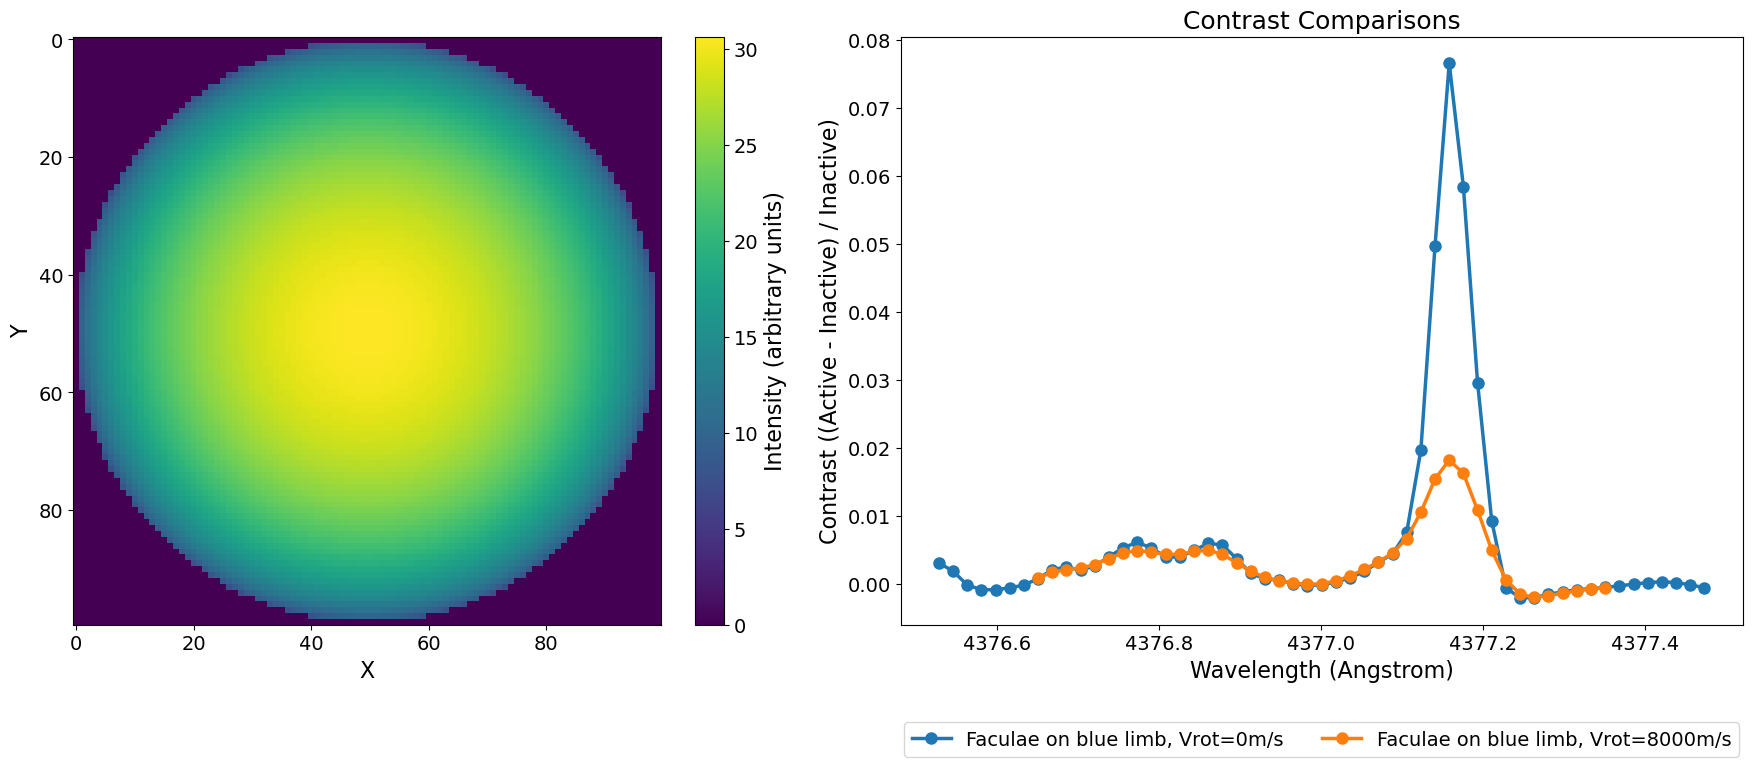

In [3]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from disk_utils import process_disk_directory, get_simulation_params

# Set larger font sizes for LaTeX readability
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'lines.markersize': 8
})

# =========================================================
# Part 1: Intensity Map Setup
# =========================================================
directory = './1_4376.5109_4377.4913_fac_lat0_long0_r0_v0/'

# Print simulation parameters from first csv
first_csv = next(Path('.').glob(f'{directory}/wavelength_shifts_inp*.csv'), None)
if first_csv:
    with open(first_csv, 'r') as f:
        header = f.readline()
        print("Simulation Parameters:")
        print(header.strip(), '\n')
else:
    print("No .csv files found to read the header from.")

# Load intensity maps
npy_files = sorted(Path('.').glob(f'{directory}/disk_inp*.npy'))
if not npy_files:
    raise FileNotFoundError("No files found matching pattern: disk_inp*.npy")

def parse_wavelength(p):
    m = re.search(r'inp([0-9.]+)\.npy$', p.name)
    return float(m.group(1)) if m else np.nan

intensity_maps = {}
for f in npy_files:
    wl = parse_wavelength(f)
    intensity_maps[wl] = np.load(f)

# =========================================================
# Part 2: Contrast Setup
# =========================================================
use_explicit_dirs = True
explicit_active_dirs = [
    './1_4376.5109_4377.4913_fac_lat0_long0_r15_v0/',
    './1_4376.5109_4377.4913_fac_lat0_long0_r15_v8000/',


    # './1_4376.5109_4377.4913_fac_lat0_long45_r15_v2000/',
    # './1_4376.5109_4377.4913_fac_lat0_long45_r15_v4000/',
    # './1_4376.5109_4377.4913_fac_lat0_long45_r15_v8000/',
]

if use_explicit_dirs:
    active_dirs = explicit_active_dirs
else:
    search_strings = ['facline_removed']
    active_dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        and all(s in d for s in search_strings)
    ])

comparisons = []
for active in active_dirs:
    inactive = re.sub(r'lat-?\d+', 'lat0', active)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)
    
    if active != inactive:
        comparisons.append((active, inactive))

def extract_features(dir_path):
    folder = dir_path.strip('./')
    idx = folder.find('_fac_')
    if idx != -1:
        return folder[idx + 1:] 
    return folder[idx:]

# =========================================================
# Part 3: Create Subplots
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), dpi=100)

# --- Left subplot: Intensity map ---
plot_wl = sorted(intensity_maps.keys())[0]
idx = 0
img_data = intensity_maps[plot_wl][idx]

im = ax1.imshow(img_data, cmap='viridis')
#ax1.set_title(f'Intensity Map (Wavelength {plot_wl} | Phase {idx})')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Intensity (arbitrary units)')

# --- Right subplot: Contrast comparisons ---
if comparisons:
    for dir_active, dir_inactive in comparisons:
        try:
            bin_centers_active, binned_intensity_active = process_disk_directory(dir_active, phase_idx=0)
            bin_centers_inactive, binned_intensity_inactive = process_disk_directory(dir_inactive, phase_idx=0)

            contrast = (binned_intensity_active - binned_intensity_inactive) / binned_intensity_inactive

            v_match = re.search(r'_v(\d+)', dir_active)
            velocity = v_match.group(1) if v_match else "unknown"

            ax2.plot(bin_centers_active, contrast, linestyle='-', linewidth=2.5, alpha=1.0,
                     marker='o', markersize=8,
                     label=f'Faculae on blue limb, Vrot={velocity}m/s')
                     
        except Exception as e:
            print(f"Error processing contrast for {dir_active} vs {dir_inactive}: {e}")

    ax2.set_xlabel('Wavelength (Angstrom)')
    ax2.set_ylabel('Contrast ((Active - Inactive) / Inactive)')
    ax2.set_title('Contrast Comparisons')
    # Place legend below the plot to keep the area clear
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
else:
    print("Please provide at least one active directory to calculate contrast.")

# Adjust layout and save high-res png
plt.tight_layout()
plt.savefig('combined_intensity_contrast_faculae.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
#lots of things going on here. At line cores, can we see further into the disk or shallower?
#when faculae are at the limbs, we see the hot walls so it will be brighter, but only inside absorption lines?
#shouldn't the faculae contrast be brighter then at the limb
#seems like the faculae are brighter except inside line cores, where they're a little bit darker, I guess because those form deeper into the atmosphere where the contributions are more similar? Check back on this logic

#the faculae are brighter in the continuum at the limb, dimmer in the line cores at the limb

Error processing contrast for ./4376.5109_4377.4913_fac_lat0_long45_r19_v4000/ vs ./4376.5109_4377.4913_fac_lat0_long0_r0_v4000/: No disk_inp*.npy files found in 4376.5109_4377.4913_fac_lat0_long45_r19_v4000
Error processing contrast for ./4376.5109_4377.4913_fac_lat0_long45_r19_v2000/ vs ./4376.5109_4377.4913_fac_lat0_long0_r0_v2000/: No disk_inp*.npy files found in 4376.5109_4377.4913_fac_lat0_long45_r19_v2000
Error processing contrast for ./4376.5109_4377.4913_fac_lat0_long45_r19_v8000/ vs ./4376.5109_4377.4913_fac_lat0_long0_r0_v8000/: No disk_inp*.npy files found in 4376.5109_4377.4913_fac_lat0_long45_r19_v8000


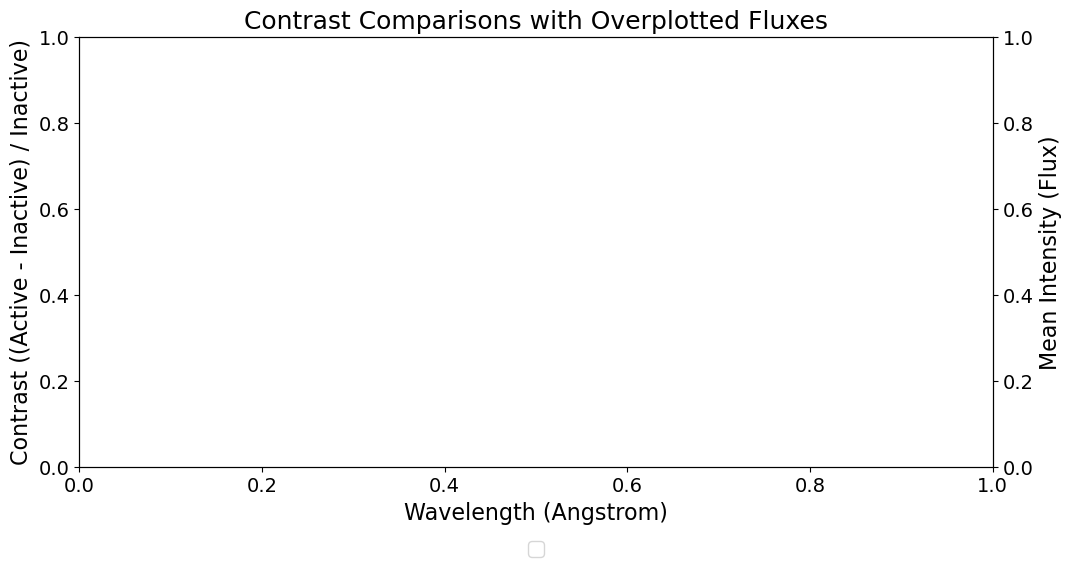

In [5]:
import os
import glob
import re
import matplotlib.pyplot as plt
from disk_utils import process_disk_directory, get_simulation_params

# Choose whether to explicitly define directories or search for them
use_explicit_dirs = True

# --- Option 1: Explicitly define active directories ---
explicit_active_dirs = [
    # './4376.5109_4377.4913_fac_lat0_long0_r15_v4000/',
    './4376.5109_4377.4913_fac_lat0_long45_r19_v4000/',
    './4376.5109_4377.4913_fac_lat0_long45_r19_v2000/',
    './4376.5109_4377.4913_fac_lat0_long45_r19_v8000/',


    # './4376.5109_4377.4913_fac_lat0_long61_r23_v4000/',

    # './4376.5109_4377.4913_fac_lat0_long0_r15_v4000_facline_removed/',
    # './4376.5109_4377.4913_fac_lat0_long45_r19_v4000_facline_removed/',

]

# --- Option 2: Define strings that MUST be present in the directory name ---
search_strings = ['facline_removed']

if use_explicit_dirs:
    active_dirs = explicit_active_dirs
else:
    active_dirs = sorted([
        d for d in glob.glob('./*/') 
        if '__pycache__' not in d 
        and 'wdrift' not in d
        and all(s in d for s in search_strings)
    ])

# Automatically generate inactive counterpart by zeroing lat, long, and r
comparisons = []
for active in active_dirs:
    inactive = re.sub(r'lat-?\d+', 'lat0', active)
    inactive = re.sub(r'long-?\d+', 'long0', inactive)
    inactive = re.sub(r'r\d+', 'r0', inactive)
    
    # Don't compare the inactive line against itself
    if active != inactive:
        comparisons.append((active, inactive))

def extract_features(dir_path):
    folder = dir_path.strip('./')
    idx = folder.find('fac_')
    return folder[idx:] if idx != -1 else folder

if comparisons:
    fig, ax1 = plt.subplots(figsize=(11, 6), dpi=100)
    ax2 = ax1.twinx()  # Create a secondary y-axis for the fluxes
    
    plotted_baselines = set()
    
    for dir_active, dir_inactive in comparisons:
        try:
            # Retrieve the binned spectrum data again for the two disks
            bin_centers_active, binned_intensity_active = process_disk_directory(dir_active, phase_idx=0)
            bin_centers_inactive, binned_intensity_inactive = process_disk_directory(dir_inactive, phase_idx=0)

            # Calculate contrast: (active - inactive) / inactive
            # Assuming both arrays share the exact same bin centers
            contrast = (binned_intensity_active - binned_intensity_inactive) / binned_intensity_inactive

            v_match = re.search(r'_v(\d+)', dir_active)
            velocity = v_match.group(1) if v_match else "unknown"
            active_label_str = f'spot on blue limb Vrot {velocity}m/s'
            label_inactive = extract_features(dir_inactive)

            # Plot contrast on primary axis (ax1)
            line = ax1.plot(bin_centers_active, contrast, linestyle='-', linewidth=2.5, alpha=1.0,
                            label=active_label_str)[0]
            color = line.get_color()
            
            # Plot the active flux on secondary axis (ax2)
            ax2.plot(bin_centers_active, binned_intensity_active, linestyle=':', linewidth=2.5, alpha=1.0, color=color,
                     label=f'Flux: {active_label_str}')
                     
            # Plot the inactive baseline flux just once per unique baseline
            if label_inactive not in plotted_baselines:
                ax2.plot(bin_centers_inactive, binned_intensity_inactive, linestyle='--', linewidth=2.5, alpha=1.0, color='black',
                         label=f'Baseline Flux: {label_inactive}')
                plotted_baselines.add(label_inactive)
                     
        except Exception as e:
            print(f"Error processing contrast for {dir_active} vs {dir_inactive}: {e}")

    # plt.axhline(0, color='black', linestyle='--', linewidth=1)

    ax1.set_xlabel('Wavelength (Angstrom)')
    ax1.set_ylabel('Contrast ((Active - Inactive) / Inactive)')
    ax2.set_ylabel('Mean Intensity (Flux)')
    
    plt.title('Contrast Comparisons with Overplotted Fluxes')
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
    
    plt.tight_layout()
    plt.show()
else:
    print("Please provide at least one active directory to calculate contrast.")